In [33]:
import pandas as pd
import numpy as np

In [34]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [35]:
df = pd.read_csv("../data/raw/stocks/AAPL.csv")

In [36]:
df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
1,Date,NaN,NaN,NaN,NaN,NaN
2,2019-01-02,37.538818359375,37.759888517261295,36.66167592649953,36.81856395762742,148158800
3,2019-01-03,33.7996711730957,34.63877937995314,33.75450611274441,34.225166520409374,365248800
4,2019-01-04,35.24256134033203,35.311498641777554,34.18238645663675,34.35591215580835,234428400


In [37]:
df.columns

Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')

In [38]:
df = df[df["Price"] != "Ticker"]
df.head()

,Price,Close,High,Low,Open,Volume
1,Date,NaN,NaN,NaN,NaN,NaN
2,2019-01-02,37.538818359375,37.759888517261295,36.66167592649953,36.81856395762742,148158800
3,2019-01-03,33.7996711730957,34.63877937995314,33.75450611274441,34.225166520409374,365248800
4,2019-01-04,35.24256134033203,35.311498641777554,34.18238645663675,34.35591215580835,234428400
5,2019-01-07,35.16411209106445,35.37805128112703,34.681565561258495,35.3471481073425,219111200


In [39]:
df.rename(columns={"Price": "Date"}, inplace=True)
df.head()

,Date,Close,High,Low,Open,Volume
1,Date,NaN,NaN,NaN,NaN,NaN
2,2019-01-02,37.538818359375,37.759888517261295,36.66167592649953,36.81856395762742,148158800
3,2019-01-03,33.7996711730957,34.63877937995314,33.75450611274441,34.225166520409374,365248800
4,2019-01-04,35.24256134033203,35.311498641777554,34.18238645663675,34.35591215580835,234428400
5,2019-01-07,35.16411209106445,35.37805128112703,34.681565561258495,35.3471481073425,219111200


In [40]:
df = df[df["Date"] != "Date"]
df.head()

,Date,Close,High,Low,Open,Volume
2,2019-01-02,37.538818359375,37.759888517261295,36.66167592649953,36.81856395762742,148158800
3,2019-01-03,33.7996711730957,34.63877937995314,33.75450611274441,34.225166520409374,365248800
4,2019-01-04,35.24256134033203,35.311498641777554,34.18238645663675,34.35591215580835,234428400
5,2019-01-07,35.16411209106445,35.37805128112703,34.681565561258495,35.3471481073425,219111200
6,2019-01-08,35.83445739746094,36.08880653095804,35.30436992220377,35.55158448343476,164101200


In [41]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df = df.reset_index(drop=True)

In [42]:
df = df[["Open", "High", "Low", "Close", "Volume"]]


In [43]:
df.isnull().sum()


Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [ ]:
#df = df.dropna()
#if exists

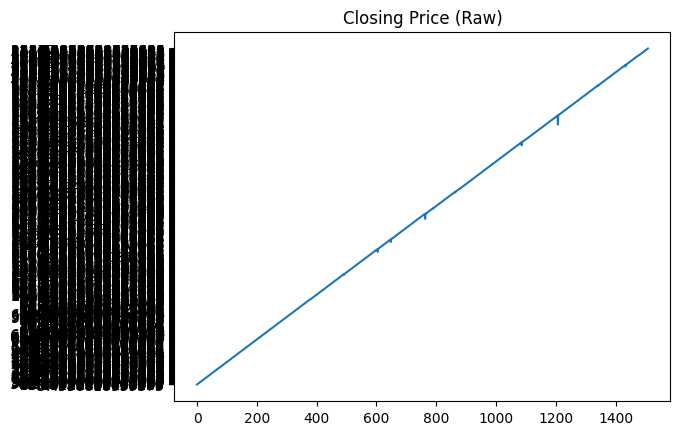

In [44]:
plt.figure()
plt.plot(df["Close"])
plt.title("Closing Price (Raw)")
plt.show()


In [45]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)

In [46]:
scaled_data.shape

(1509, 5)

In [ ]:
#Create Time-Series Sequences

def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i, 3])  # Close price index
    return np.array(X), np.array(y)


In [48]:
WINDOW_SIZE = 60
X, y = create_sequences(scaled_data, WINDOW_SIZE)

X.shape, y.shape


((1449, 60, 5), (1449,))

In [49]:
#Train / Test Split

split_ratio = 0.8
split_index = int(len(X) * split_ratio)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]



X_train.shape, X_test.shape

((1159, 60, 5), (290, 60, 5))

In [50]:
#Save Processed Data
np.save("../data/processed/X_train.npy", X_train)
np.save("../data/processed/y_train.npy", y_train)
np.save("../data/processed/X_test.npy", X_test)
np.save("../data/processed/y_test.npy", y_test)